# Sistem Prediksi Penempatan Level KIIP Berdasarkan Kemampuan Bahasa Korea
### Menggunakan Algoritma Random Forest dan XGBoost

**Nama:** _(isi nama kamu)_
**Domain Proyek:** Pendidikan / Bahasa Asing - Korean Immigration and Integration Program (KIIP)

Notebook ini mengikuti metodologi **CRISP-DM**: Business Understanding, Data Understanding, Data Preparation, Modeling, Evaluation, dan Deployment.


## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)
from xgboost import XGBClassifier

import joblib

sns.set_style('whitegrid')
%matplotlib inline


## 2. Business Understanding

**Problem Statement:**
Bagaimana cara memprediksi level penempatan KIIP (Korean Immigration and Integration Program) peserta secara otomatis, cepat, dan konsisten berdasarkan data kemampuan bahasa Korea (membaca, mendengar, menulis, berbicara, tata bahasa, kosakata), hasil tes simulasi, latar belakang pendidikan, kewarganegaraan, serta lama tinggal di Korea?

**Goals:**
- Membangun model klasifikasi yang dapat memprediksi `KIIP_Level` (0-5) peserta secara akurat.
- Membandingkan performa algoritma Random Forest dan XGBoost dalam menyelesaikan permasalahan ini.
- Mengidentifikasi fitur-fitur yang paling berpengaruh terhadap penentuan level KIIP.

**Solution Statement:**
- Membangun model **Random Forest Classifier** sebagai baseline yang robust terhadap overfitting dan mudah diinterpretasi melalui feature importance.
- Membangun model **XGBoost Classifier** sebagai model boosting yang umumnya memberikan performa lebih tinggi pada data tabular.
- Kedua model dievaluasi menggunakan metrik Accuracy, Precision, Recall, dan F1-Score (weighted average karena target bersifat multi-kelas).


## 3. Data Understanding

Dataset yang digunakan adalah **KIIP Dataset** yang memuat data kemampuan bahasa Korea dan skor tes peserta program KIIP, dengan target `KIIP_Level`.

**Fitur pada dataset:**
- `Age`: Usia peserta
- `Nationality`: Kewarganegaraan peserta
- `Study_Hours`: Total jam belajar bahasa Korea
- `Reading`, `Listening`, `Writing`, `Speaking`, `Grammar`, `Vocabulary`: Skor kemampuan bahasa Korea per aspek (skala 0-100)
- `Mock_Test`: Skor hasil tes simulasi/uji coba
- `Education`: Latar belakang pendidikan
- `TOPIK_Level`: Level sertifikasi TOPIK yang dimiliki peserta (0-6)
- `Years_in_Korea`: Lama tinggal di Korea (tahun)
- `KIIP_Level`: **(target)** Level penempatan KIIP (0-5)


In [2]:
df = pd.read_csv('kiip_dataset1.csv', sep=';')
df.head()


,Age,Nationality,Study_Hours,Reading,Listening,Writing,Speaking,Grammar,Vocabulary,Mock_Test,Education,TOPIK_Level,Years_in_Korea,KIIP_Level
0,50,Indonesia,675,100,100,100,100,100,100,102,Diploma,4,"4,1",5
1,35,China,716,100,94,91,100,100,100,93,Diploma,5,"4,6",5
2,41,Mongolia,342,70,68,59,69,63,66,68,High School,3,2,2
3,41,Thailand,94,43,32,28,55,38,45,41,Diploma,0,0,0
4,21,Mongolia,737,97,100,93,91,100,100,94,High School,5,"4,7",5


In [3]:
df.shape


(1500, 14)

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Age             1500 non-null   int64
 1   Nationality     1500 non-null   str  
 2   Study_Hours     1500 non-null   int64
 3   Reading         1500 non-null   int64
 4   Listening       1500 non-null   int64
 5   Writing         1500 non-null   int64
 6   Speaking        1500 non-null   int64
 7   Grammar         1500 non-null   int64
 8   Vocabulary      1500 non-null   int64
 9   Mock_Test       1500 non-null   int64
 10  Education       1500 non-null   str  
 11  TOPIK_Level     1500 non-null   int64
 12  Years_in_Korea  1500 non-null   str  
 13  KIIP_Level      1500 non-null   int64
dtypes: int64(11), str(3)
memory usage: 164.2 KB


In [5]:
# Konversi Years_in_Korea dari format string koma desimal menjadi float
df['Years_in_Korea'] = df['Years_in_Korea'].astype(str).str.replace(',', '.').astype(float)
df[['Years_in_Korea']].describe()


,Years_in_Korea
count,1500.000000
mean,2.350667
std,1.405842
min,0.000000
25%,1.200000
50%,2.400000
75%,3.500000
max,6.200000


In [6]:
# Pengecekan missing values
df.isnull().sum()


Age               0
Nationality       0
Study_Hours       0
Reading           0
Listening         0
Writing           0
Speaking          0
Grammar           0
Vocabulary        0
Mock_Test         0
Education         0
TOPIK_Level       0
Years_in_Korea    0
KIIP_Level        0
dtype: int64

In [7]:
# Pengecekan data duplikat
print("Jumlah data duplikat:", df.duplicated().sum())


Jumlah data duplikat: 0


In [8]:
df.describe()


,Age,Study_Hours,Reading,Listening,Writing,Speaking,Grammar,Vocabulary,Mock_Test,TOPIK_Level,Years_in_Korea,KIIP_Level
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,36.272667,425.660667,69.662667,69.610667,69.907333,69.542667,69.715333,69.764667,69.064667,2.558000,2.350667,2.544667
std,10.912579,204.600302,20.927642,20.920585,20.729204,20.806140,21.149543,20.761069,19.909480,1.755189,1.405842,1.682625
min,18.000000,10.000000,14.000000,19.000000,14.000000,14.000000,16.000000,19.000000,28.000000,0.000000,0.000000,0.000000
25%,27.000000,249.000000,52.000000,52.000000,53.000000,52.750000,53.000000,53.000000,52.000000,1.000000,1.200000,1.000000
50%,36.000000,431.000000,71.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,3.000000,2.400000,3.000000
75%,46.000000,600.000000,88.000000,88.000000,89.000000,87.000000,89.000000,88.000000,87.000000,4.000000,3.500000,4.000000
max,55.000000,819.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,106.000000,6.000000,6.200000,5.000000


In [9]:
# Distribusi kelas target
df['KIIP_Level'].value_counts().sort_index()


KIIP_Level
0    224
1    258
2    251
3    261
4    256
5    250
Name: count, dtype: int64

### Exploratory Data Analysis (EDA)

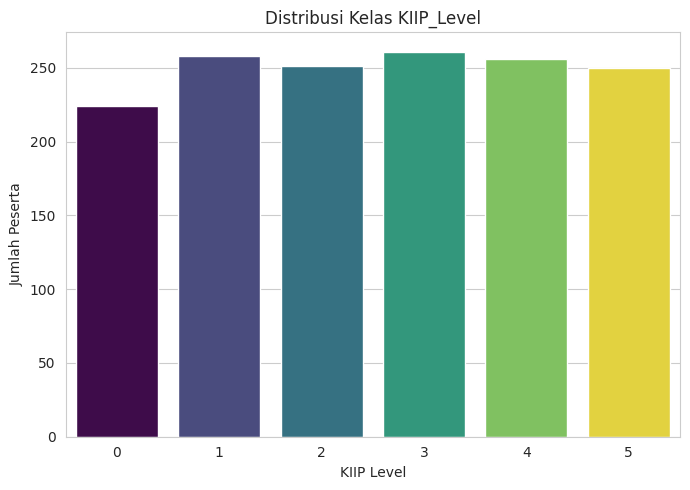

In [10]:
plt.figure(figsize=(7,5))
sns.countplot(x='KIIP_Level', data=df, hue='KIIP_Level', palette='viridis', legend=False)
plt.title('Distribusi Kelas KIIP_Level')
plt.xlabel('KIIP Level'); plt.ylabel('Jumlah Peserta')
plt.tight_layout()
plt.savefig('images/01_distribusi_target.png', dpi=120)
plt.show()


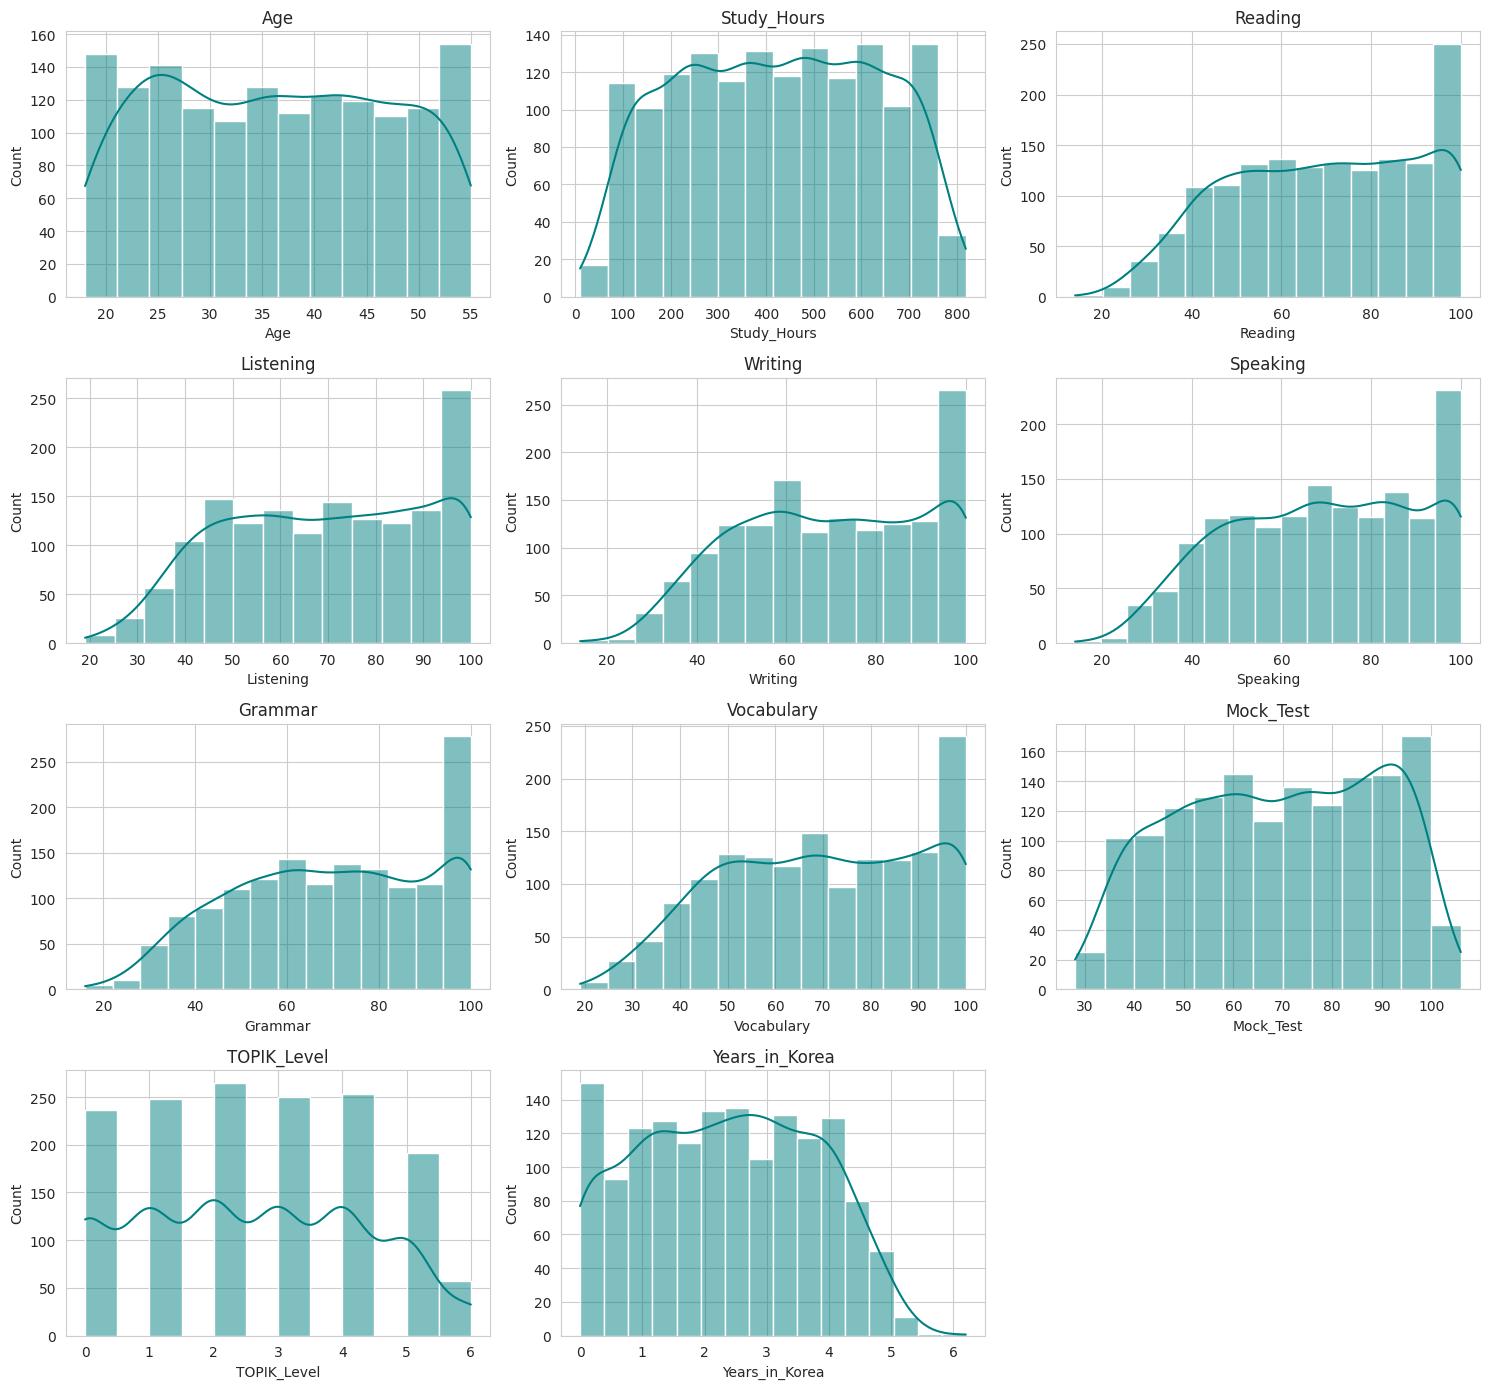

In [11]:
num_feats = ['Age','Study_Hours','Reading','Listening','Writing','Speaking',
             'Grammar','Vocabulary','Mock_Test','TOPIK_Level','Years_in_Korea']

fig, axes = plt.subplots(4,3, figsize=(15,14))
axes = axes.flatten()
for i, col in enumerate(num_feats):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(col)
for j in range(len(num_feats), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig('images/02_histogram_fitur.png', dpi=120)
plt.show()


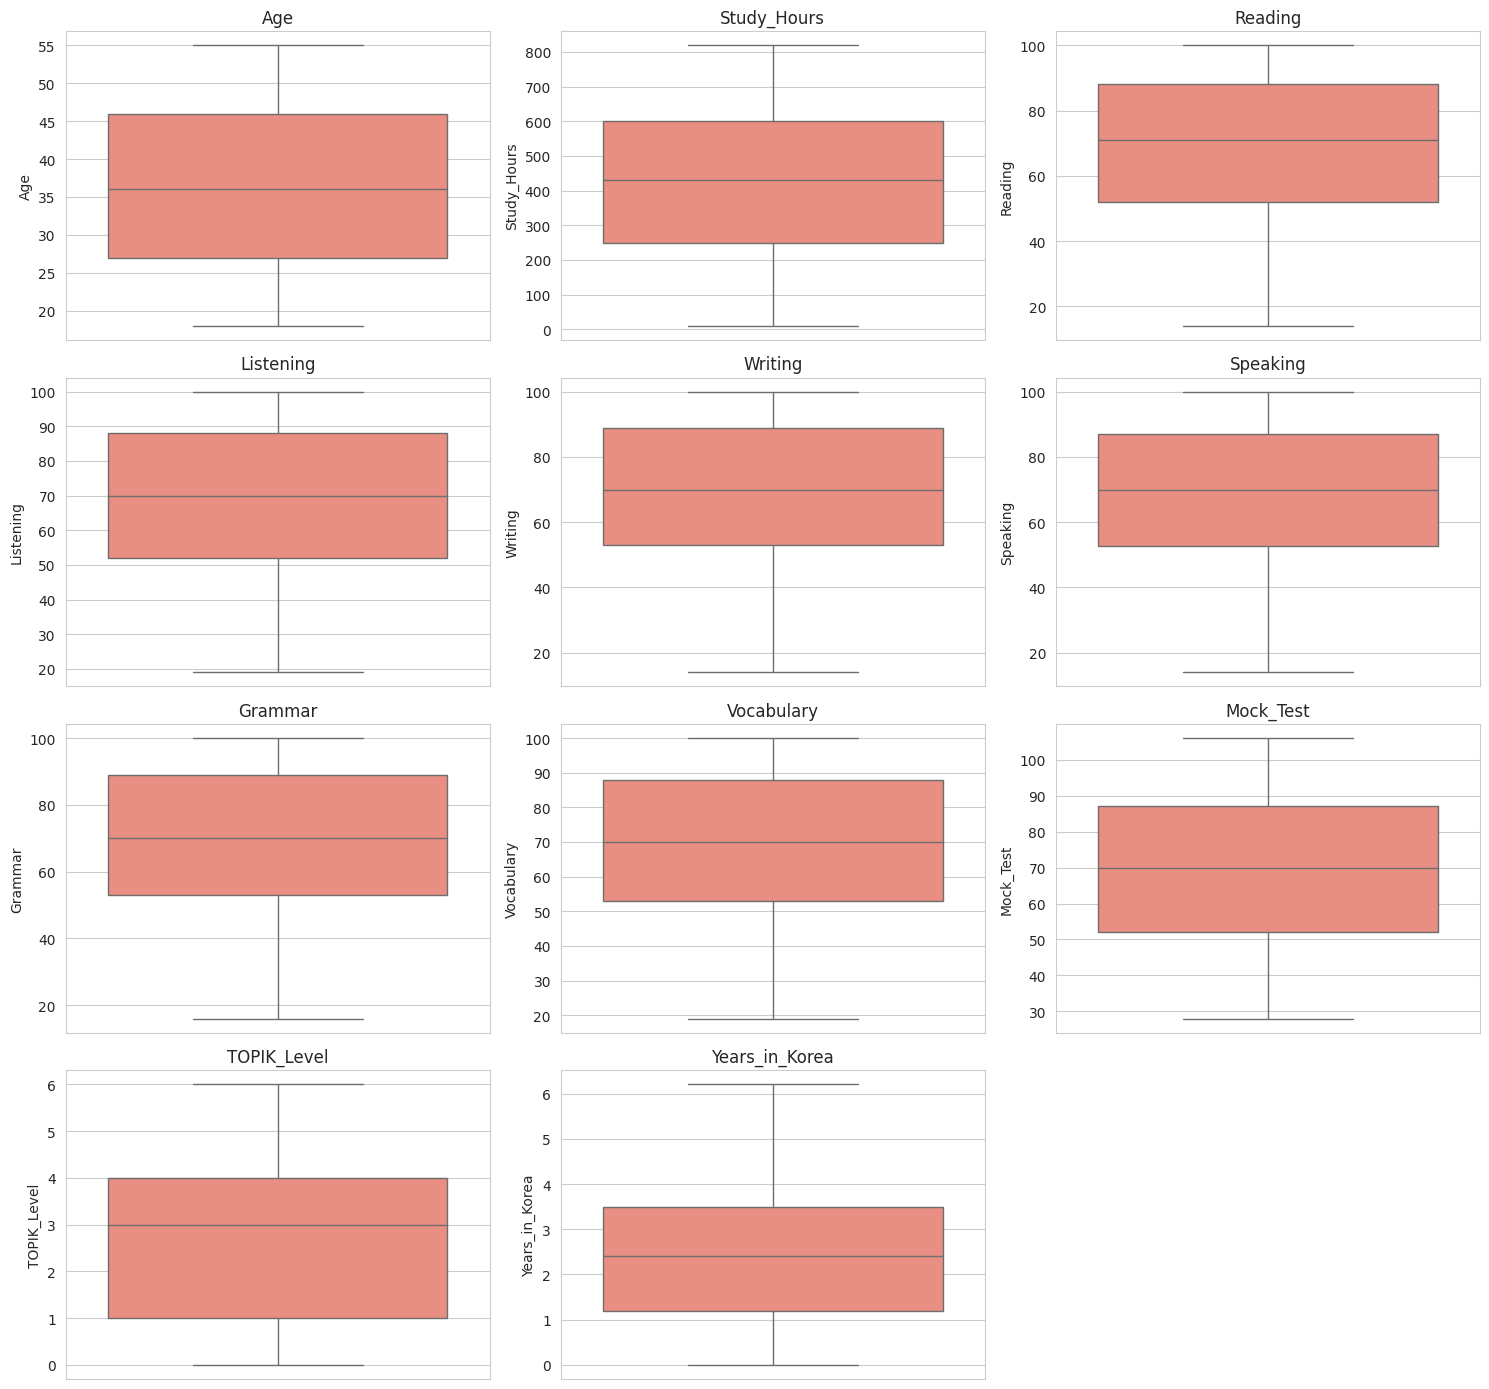

In [12]:
fig, axes = plt.subplots(4,3, figsize=(15,14))
axes = axes.flatten()
for i, col in enumerate(num_feats):
    sns.boxplot(y=df[col], ax=axes[i], color='salmon')
    axes[i].set_title(col)
for j in range(len(num_feats), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig('images/03_boxplot_outlier.png', dpi=120)
plt.show()


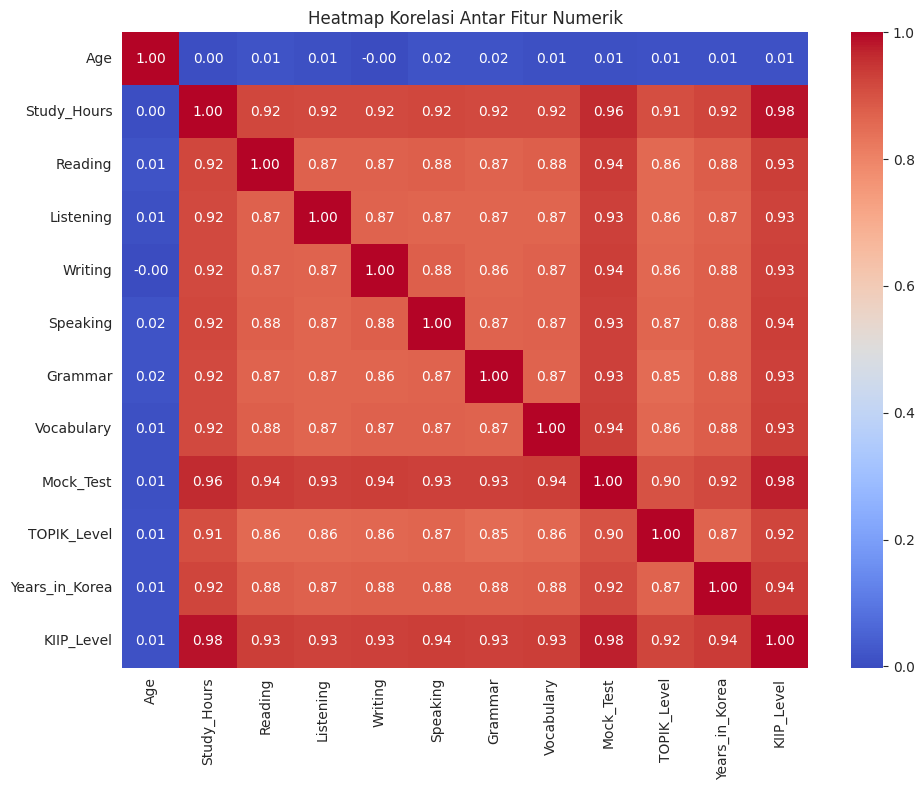

In [13]:
plt.figure(figsize=(10,8))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Heatmap Korelasi Antar Fitur Numerik')
plt.tight_layout()
plt.savefig('images/04_heatmap_korelasi.png', dpi=120)
plt.show()


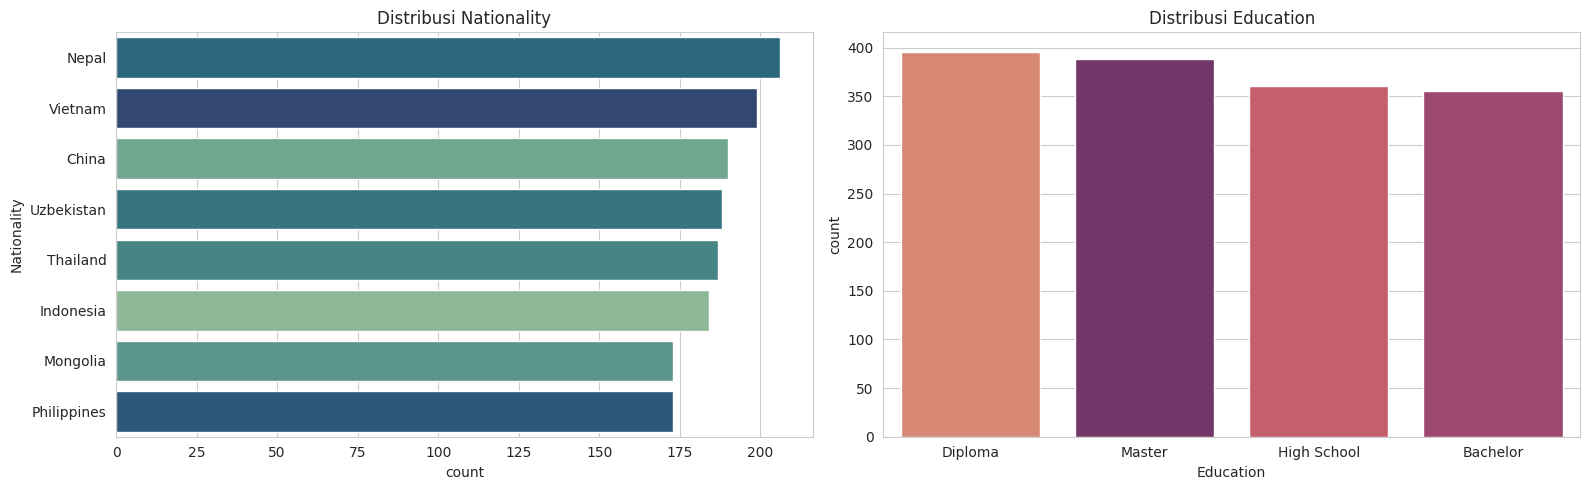

In [14]:
fig, axes = plt.subplots(1,2, figsize=(16,5))
sns.countplot(y='Nationality', data=df, hue='Nationality', legend=False,
              order=df['Nationality'].value_counts().index, ax=axes[0], palette='crest')
axes[0].set_title('Distribusi Nationality')
sns.countplot(x='Education', data=df, hue='Education', legend=False,
              order=df['Education'].value_counts().index, ax=axes[1], palette='flare')
axes[1].set_title('Distribusi Education')
plt.tight_layout()
plt.savefig('images/05_distribusi_kategorikal.png', dpi=120)
plt.show()


**Insight EDA:**
- Distribusi kelas target `KIIP_Level` relatif **seimbang** (masing-masing kelas berkisar 224-261 data dari total 1500), sehingga tidak diperlukan teknik penyeimbangan kelas khusus (misalnya SMOTE).
- Tidak ditemukan missing values maupun data duplikat.
- Fitur-fitur skor kemampuan bahasa (`Reading`, `Listening`, `Writing`, `Speaking`, `Grammar`, `Vocabulary`), `Study_Hours`, `Mock_Test`, `TOPIK_Level`, dan `Years_in_Korea` menunjukkan korelasi yang **sangat tinggi** terhadap `KIIP_Level` (>0.9), sementara `Age` hampir tidak berkorelasi.
- Korelasi yang sangat tinggi ini mengindikasikan bahwa `KIIP_Level` pada dataset kemungkinan besar dihasilkan secara sintetis/berbasis aturan dari skor-skor tersebut. Hal ini perlu dicatat sebagai catatan/limitasi dataset di bagian Evaluation.


## 4. Data Preparation

Tahapan yang dilakukan:
1. **Encoding fitur kategorikal**: `Nationality` dan `Education` diubah menjadi numerik menggunakan `LabelEncoder`.
2. **Pemilihan fitur**: seluruh fitur kecuali `KIIP_Level` (target) digunakan sebagai prediktor.
3. **Train-test split**: 80% data latih, 20% data uji, dengan `stratify=y` agar proporsi tiap kelas tetap terjaga di kedua subset.
4. **Standardisasi** menggunakan `StandardScaler` (disiapkan untuk keperluan model lain/analisis lanjutan; Random Forest & XGBoost secara umum tidak mensyaratkan scaling karena berbasis pohon keputusan, namun scaler tetap disimpan agar pipeline konsisten saat deployment).


In [15]:
le_nat = LabelEncoder()
le_edu = LabelEncoder()

df['Nationality_enc'] = le_nat.fit_transform(df['Nationality'])
df['Education_enc'] = le_edu.fit_transform(df['Education'])

feature_cols = ['Age','Nationality_enc','Study_Hours','Reading','Listening','Writing',
                 'Speaking','Grammar','Vocabulary','Mock_Test','Education_enc',
                 'TOPIK_Level','Years_in_Korea']

X = df[feature_cols]
y = df['KIIP_Level']

X.head()


,Age,Nationality_enc,Study_Hours,Reading,Listening,Writing,Speaking,Grammar,Vocabulary,Mock_Test,Education_enc,TOPIK_Level,Years_in_Korea
0,50,1,675,100,100,100,100,100,100,102,1,4,4.1
1,35,0,716,100,94,91,100,100,100,93,1,5,4.6
2,41,2,342,70,68,59,69,63,66,68,2,3,2.0
3,41,5,94,43,32,28,55,38,45,41,1,0,0.0
4,21,2,737,97,100,93,91,100,100,94,2,5,4.7


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data latih :", X_train.shape)
print("Data uji   :", X_test.shape)


Data latih : (1200, 13)
Data uji   : (300, 13)


In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 5. Modeling

### 5.1 Random Forest Classifier
Random Forest adalah algoritma *ensemble learning* berbasis kumpulan pohon keputusan (decision tree) yang dilatih pada subset data dan fitur secara acak (*bagging*), kemudian hasil prediksinya digabungkan melalui voting mayoritas.

**Parameter yang digunakan:**
- `n_estimators=200` — jumlah pohon dalam forest
- `max_depth=None` — pohon dibiarkan tumbuh hingga daun murni (default)
- `random_state=42` — memastikan hasil dapat direproduksi

### 5.2 XGBoost Classifier
XGBoost (Extreme Gradient Boosting) adalah algoritma *ensemble learning* berbasis *boosting*, di mana setiap pohon baru dibangun untuk memperbaiki kesalahan (residual error) dari pohon sebelumnya secara sekuensial. Algoritma ini **belum diajarkan di kelas** dan dipilih sebagai bentuk eksplorasi mandiri (poin plus).

**Parameter yang digunakan:**
- `n_estimators=200` — jumlah boosting round
- `max_depth=6` — kedalaman maksimum tiap pohon
- `learning_rate=0.1` — laju kontribusi tiap pohon terhadap prediksi akhir
- `eval_metric='mlogloss'` — metrik loss untuk klasifikasi multi-kelas


In [18]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("Random Forest selesai dilatih.")


Random Forest selesai dilatih.


In [19]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
print("XGBoost selesai dilatih.")


XGBoost selesai dilatih.


## 6. Evaluation

Metrik yang digunakan untuk mengevaluasi model klasifikasi multi-kelas ini:
- **Accuracy**: proporsi prediksi yang benar dari keseluruhan data.
- **Precision (weighted)**: rata-rata precision tiap kelas, dibobot berdasarkan jumlah sampel tiap kelas.
- **Recall (weighted)**: rata-rata recall tiap kelas, dibobot berdasarkan jumlah sampel tiap kelas.
- **F1-Score (weighted)**: harmonic mean dari precision dan recall, dibobot berdasarkan jumlah sampel tiap kelas.


In [20]:
def get_metrics(y_true, y_pred, name):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (weighted)': precision_score(y_true, y_pred, average='weighted'),
        'Recall (weighted)': recall_score(y_true, y_pred, average='weighted'),
        'F1-Score (weighted)': f1_score(y_true, y_pred, average='weighted')
    }

results = pd.DataFrame([
    get_metrics(y_test, rf_pred, 'Random Forest'),
    get_metrics(y_test, xgb_pred, 'XGBoost')
])
results


,Model,Accuracy,Precision (weighted),Recall (weighted),F1-Score (weighted)
0,Random Forest,0.996667,0.996732,0.996667,0.996667
1,XGBoost,0.986667,0.986796,0.986667,0.986634


In [21]:
print("Classification Report - Random Forest")
print(classification_report(y_test, rf_pred))

print("Classification Report - XGBoost")
print(classification_report(y_test, xgb_pred))


Classification Report - Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       1.00      1.00      1.00        52
           2       0.98      1.00      0.99        50
           3       1.00      0.98      0.99        52
           4       1.00      1.00      1.00        51
           5       1.00      1.00      1.00        50

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

Classification Report - XGBoost
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        45
           1       0.98      0.98      0.98        52
           2       0.98      1.00      0.99        50
           3       1.00      0.96      0.98        52
           4       0.98      1.00      0.99        51
           5       1.00      1.00      1.00        50

    acc

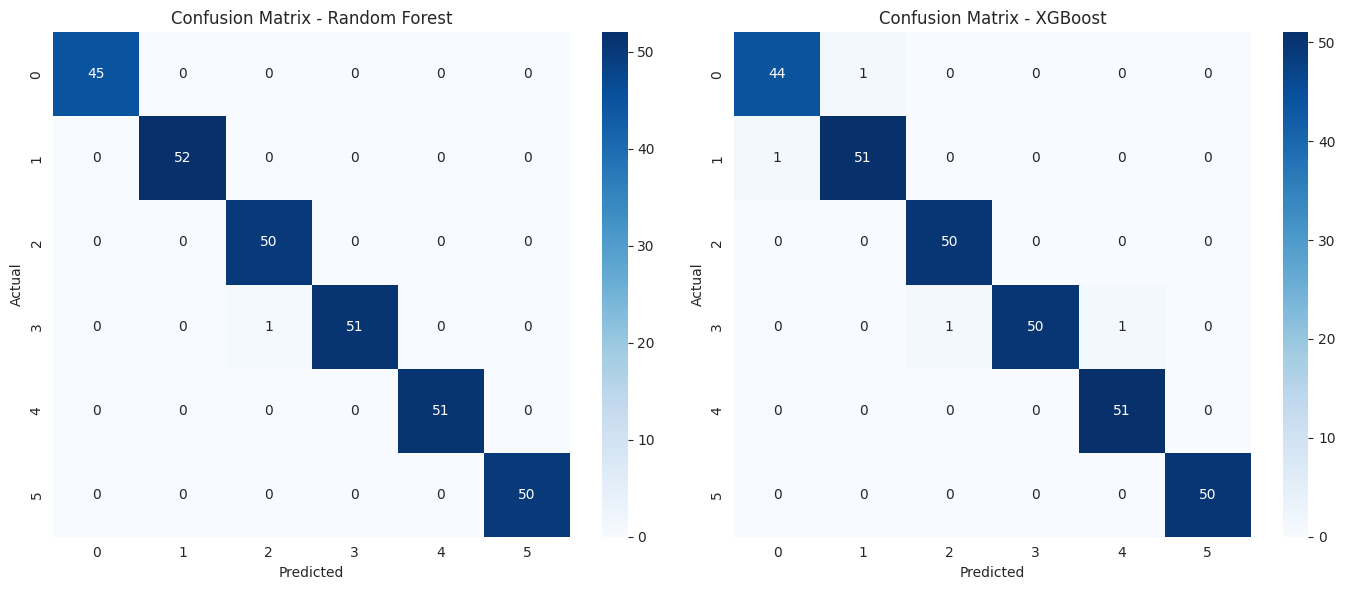

In [22]:
fig, axes = plt.subplots(1,2, figsize=(14,6))
for ax, pred, name in zip(axes, [rf_pred, xgb_pred], ['Random Forest','XGBoost']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('images/06_confusion_matrix.png', dpi=120)
plt.show()


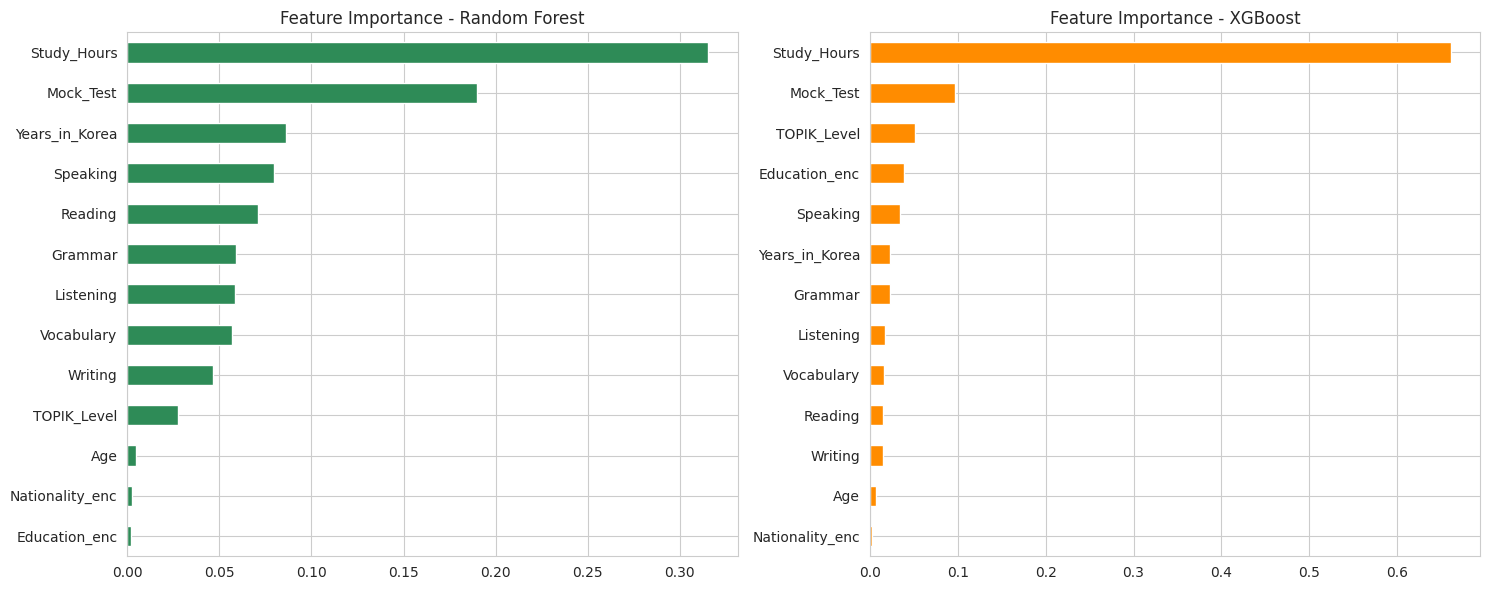

In [23]:
fig, axes = plt.subplots(1,2, figsize=(15,6))
rf_imp = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values()
xgb_imp = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values()

rf_imp.plot(kind='barh', ax=axes[0], color='seagreen')
axes[0].set_title('Feature Importance - Random Forest')

xgb_imp.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Feature Importance - XGBoost')

plt.tight_layout()
plt.savefig('images/07_feature_importance.png', dpi=120)
plt.show()


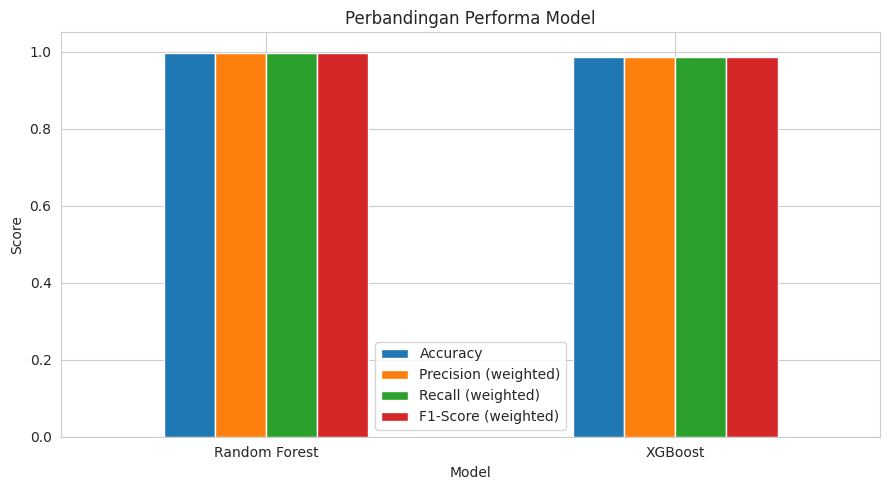

In [24]:
results.set_index('Model')[['Accuracy','Precision (weighted)','Recall (weighted)','F1-Score (weighted)']].plot(
    kind='bar', figsize=(9,5)
)
plt.title('Perbandingan Performa Model')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0,1.05)
plt.tight_layout()
plt.savefig('images/08_model_comparison.png', dpi=120)
plt.show()


**Catatan Evaluasi:**
Kedua model menunjukkan performa yang sangat tinggi (>98% pada seluruh metrik). Hal ini konsisten dengan temuan pada tahap EDA bahwa fitur `Study_Hours`, `Mock_Test`, dan skor kemampuan bahasa memiliki korelasi sangat tinggi terhadap `KIIP_Level`, sehingga pola hubungan antara fitur dan target relatif mudah dipelajari oleh model berbasis pohon keputusan. Pada penerapan di dunia nyata dengan data yang lebih variatif/noisy, performa model kemungkinan akan sedikit lebih rendah dibanding hasil pada dataset ini.


## 7. Menyimpan Model untuk Deployment

Model, scaler, dan encoder disimpan dalam format `.pkl` menggunakan `joblib` agar dapat dimuat kembali pada aplikasi deployment (Hugging Face Spaces).


In [25]:
import os
os.makedirs('deployment', exist_ok=True)

joblib.dump(rf_model, 'deployment/rf_model.pkl')
joblib.dump(xgb_model, 'deployment/xgb_model.pkl')
joblib.dump(scaler, 'deployment/scaler.pkl')
joblib.dump(le_nat, 'deployment/le_nationality.pkl')
joblib.dump(le_edu, 'deployment/le_education.pkl')
joblib.dump(feature_cols, 'deployment/feature_cols.pkl')

print("Semua artefak model berhasil disimpan di folder 'deployment/'.")


Semua artefak model berhasil disimpan di folder 'deployment/'.


## 8. Deployment

Model terbaik (berdasarkan hasil evaluasi di atas) di-deploy menggunakan **Gradio** dan di-hosting pada **Hugging Face Spaces**. Silakan lihat folder `deployment/` yang berisi `app.py` dan `requirements.txt` untuk detail implementasi, serta link Space yang telah dideploy pada README.md repository ini.
